#since KNN is all about distance and numbers Scaling is the most important feature here

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [5]:
df = pd.read_csv("cleaned_data.csv")

In [6]:
X = df.drop("GoodFT", axis=1)
y = df["GoodFT"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# n_neighbors=5 means it will look at the 5 most statistically similar players to make its guess
knn_model = KNeighborsClassifier(n_neighbors=5)

In [11]:
knn_model.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [12]:
y_pred = knn_model.predict(X_test_scaled)

In [14]:
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Accuracy: {accuracy * 100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

KNN Accuracy: 65.35%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.62      0.63      1920
           1       0.66      0.69      0.68      2126

    accuracy                           0.65      4046
   macro avg       0.65      0.65      0.65      4046
weighted avg       0.65      0.65      0.65      4046



In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [16]:
cm = confusion_matrix(y_test, y_pred)

<Axes: >

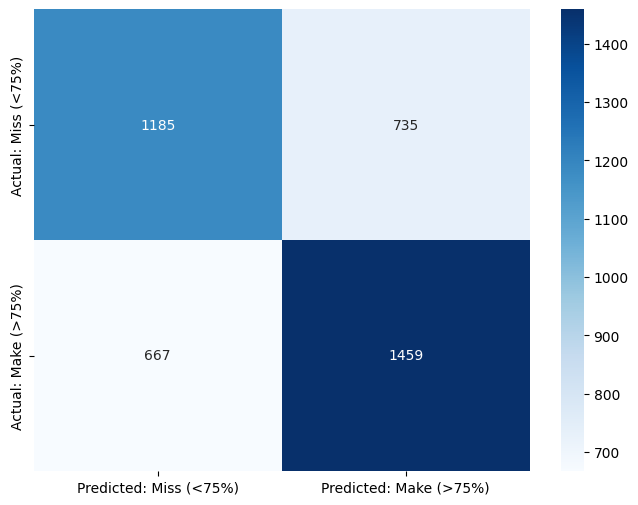

In [17]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted: Miss (<75%)', 'Predicted: Make (>75%)'], 
            yticklabels=['Actual: Miss (<75%)', 'Actual: Make (>75%)'])

In [18]:
plt.savefig('knn_confusion_matrix.png', bbox_inches='tight')

<Figure size 640x480 with 0 Axes>